In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ─── 1. CHARGEMENT DES DONNÉES AMHCD ────────────────────
AMHCD_PATH = "../data/AMHCD_64/AMHCD_64"

def load_amhcd(root_path):
    images, labels = [], []
    class_names = sorted(os.listdir(root_path))  # ordre alphabétique = reproductible
    class_names = [c for c in class_names if os.path.isdir(os.path.join(root_path, c))]
    
    for label_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(root_path, class_name)
        for img_file in os.listdir(class_folder):
            try:
                img = Image.open(os.path.join(class_folder, img_file)).convert("L")
                img = img.resize((28, 28))
                images.append(np.array(img))
                labels.append(label_idx)
            except:
                pass

    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_amhcd(AMHCD_PATH)
labels = np.array(labels)

print(f"Images chargées : {images.shape}")
print(f"Nombre de classes : {len(class_names)}")
print(f"Classes : {class_names}")
print(f"Images par classe : min={np.bincount(labels).min()}, max={np.bincount(labels).max()}")


C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

Images chargées : (25740, 28, 28)
Nombre de classes : 33
Classes : ['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagh', 'yagw', 'yah', 'yahh', 'yaj', 'yak', 'yakw', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']
Images par classe : min=780, max=780



Avant : min=43, max=255
Après : min=0.17, max=1.00


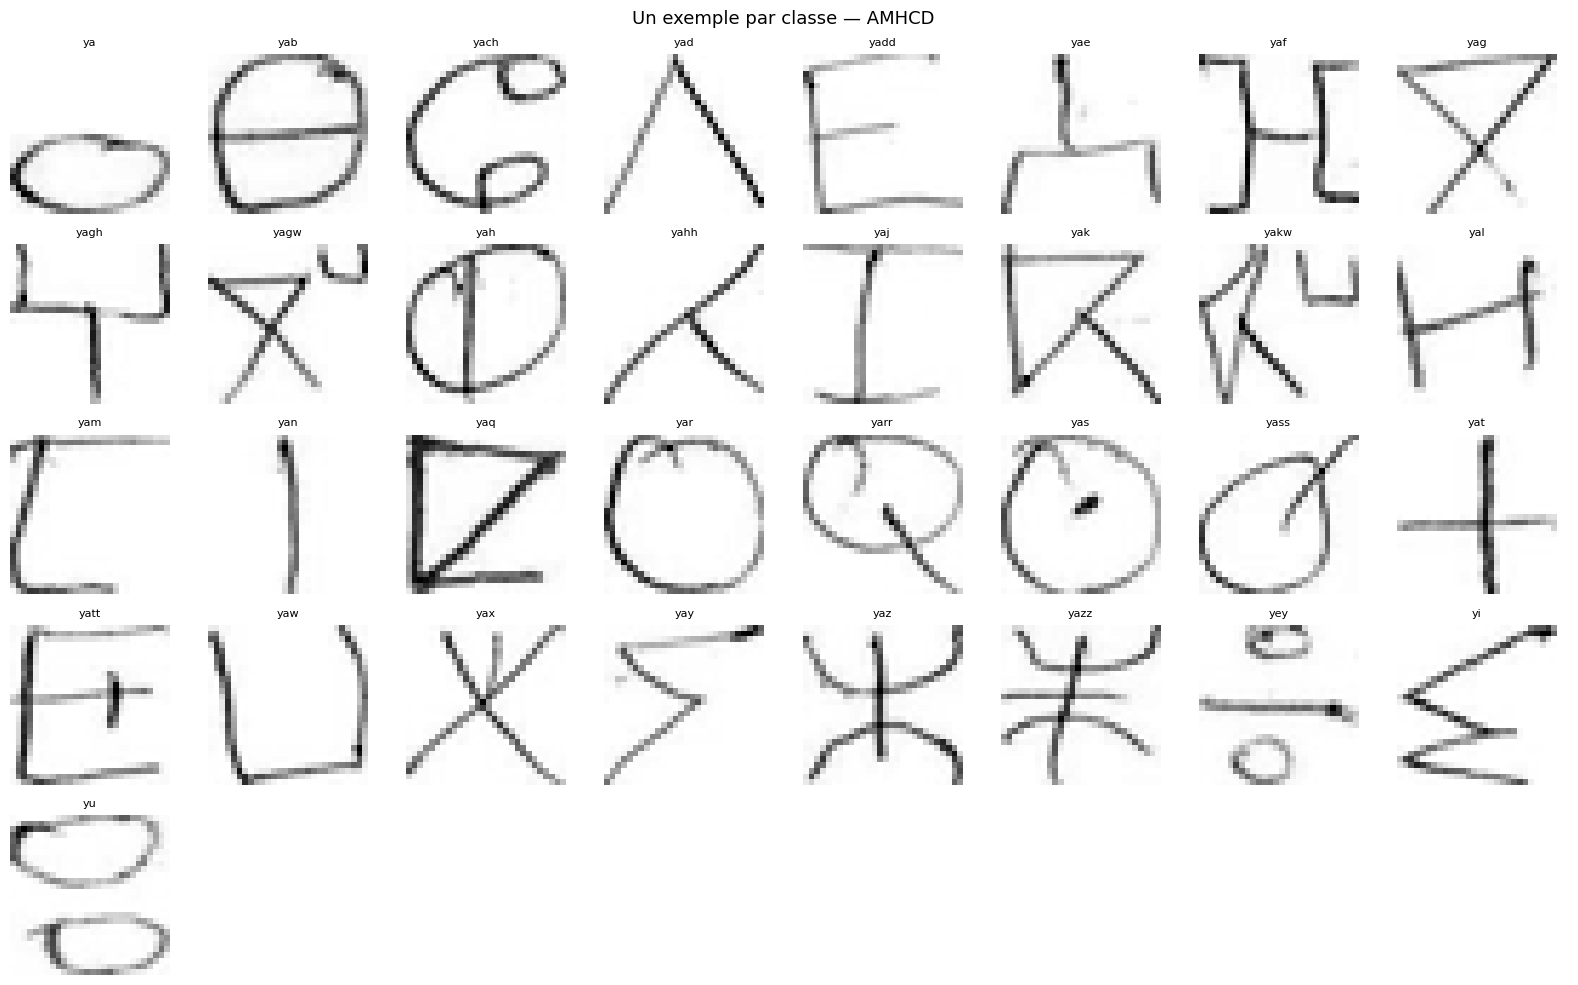


Shape après reshape : (25740, 28, 28, 1)
Shape des labels   : (25740, 33)


In [2]:
# ─── 2. NORMALISATION (0-255 → 0-1) ───────────────────────
images_normalized = images / 255.0

print(f"\nAvant : min={images.min()}, max={images.max()}")
print(f"Après : min={images_normalized.min():.2f}, max={images_normalized.max():.2f}")


# ─── 3. VISUALISATION UN EXEMPLE PAR CLASSE ───────────────
n_classes = len(class_names)
cols = 8
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)[0][0]
    axes[i].imshow(images_normalized[idx], cmap="gray")
    axes[i].set_title(class_name, fontsize=8)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Un exemple par classe — AMHCD", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/exemples_classes.png")
plt.show()


# ─── 4. RESHAPE POUR CNN ──────────────────────────────────
X = images_normalized.reshape(-1, 28, 28, 1)
print(f"\nShape après reshape : {X.shape}")


# ─── 5. ENCODAGE DES LABELS ───────────────────────────────
y = to_categorical(labels, num_classes=len(class_names))
print(f"Shape des labels   : {y.shape}")



In [3]:
# ─── 6. SPLIT TRAIN / VALIDATION / TEST ───────────────────
# 85% train+val / 15% test
X_temp, X_test, y_temp, y_test, labels_temp, _ = train_test_split(
    X, y, labels,
    test_size=0.15,
    random_state=42,
    stratify=labels       # répartition équilibrée des classes
)

# 70% train / 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=labels_temp  # labels issus du split précédent (pas de data leakage)
)

print(f"\n=== Split du dataset ===")
print(f"Train      : {X_train.shape[0]} images  (~70%)")
print(f"Validation : {X_val.shape[0]} images  (~15%)")
print(f"Test       : {X_test.shape[0]} images  (~15%)")




=== Split du dataset ===
Train      : 18028 images  (~70%)
Validation : 3851 images  (~15%)
Test       : 3861 images  (~15%)


In [4]:


# ─── 7. SAUVEGARDE ────────────────────────────────────────
np.save("../data/X_train.npy", X_train)
np.save("../data/X_val.npy",   X_val)
np.save("../data/X_test.npy",  X_test)
np.save("../data/y_train.npy", y_train)
np.save("../data/y_val.npy",   y_val)
np.save("../data/y_test.npy",  y_test)

# Sauvegarde des noms de classes pour les utiliser dans le notebook CNN
np.save("../data/class_names.npy", np.array(class_names))

print("\n Données sauvegardées dans /data/")
print(f"   Noms des classes : {class_names}")


 Données sauvegardées dans /data/
   Noms des classes : ['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagh', 'yagw', 'yah', 'yahh', 'yaj', 'yak', 'yakw', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']
